**CATS API**

In [ ]:
import requests
import json
import os
import pandas as pd

def extract_cat_data(limit=10):
    url = f"https://api.thecatapi.com/v1/images/search?limit={limit}"

    response = requests.get(url)
    data = response.json()

    os.makedirs("cat_data", exist_ok=True)
    with open("cat_data/cats.json", "w") as f:
        json.dump(data, f)

    return pd.DataFrame(data)


In [ ]:
def download_cat_pictures():
    with open("cat_data/cats.json", "r") as f:
        cats = json.load(f)

    os.makedirs("pixel_cats", exist_ok=True)

    for i, cat in enumerate(cats):
        url = cat.get('url')
        try:

            img_data = requests.get(url, timeout=10).content
            file_path = f"pixel_cats/cat_{i}.jpg"

            with open(file_path, "wb") as f:
                f.write(img_data)
            print(f"✔️ Downloaded: {file_path}")

        except Exception as e:
            print(f"❌ Failed to download cat {i}: {e}")

download_cat_pictures()

✔️ Downloaded: pixel_cats/cat_0.jpg
✔️ Downloaded: pixel_cats/cat_1.jpg
✔️ Downloaded: pixel_cats/cat_2.jpg
✔️ Downloaded: pixel_cats/cat_3.jpg
✔️ Downloaded: pixel_cats/cat_4.jpg
✔️ Downloaded: pixel_cats/cat_5.jpg
✔️ Downloaded: pixel_cats/cat_6.jpg
✔️ Downloaded: pixel_cats/cat_7.jpg
✔️ Downloaded: pixel_cats/cat_8.jpg
✔️ Downloaded: pixel_cats/cat_9.jpg


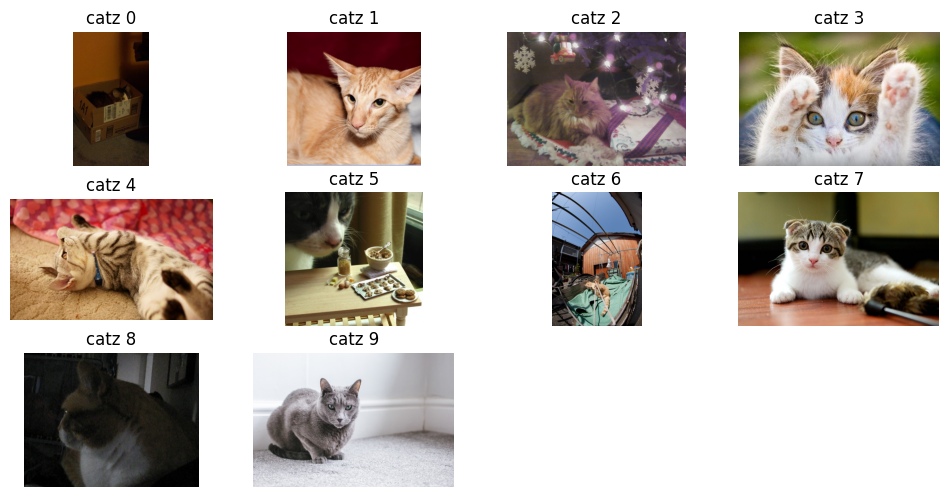

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_cat_gallery():
    cat_files = [f for f in os.listdir("pixel_cats") if f.endswith(".jpg")]

    plt.figure(figsize=(12, 8))
    for i, name in enumerate(cat_files[:10]):
        img_path = os.path.join("pixel_cats", name)
        img = mpimg.imread(img_path)

        plt.subplot(4, 4, i+1)
        plt.imshow(img)
        plt.title(f"catz {i}")
        plt.axis('off')
    plt.show()

show_cat_gallery()